In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

print("Librerías importadas correctamente ✅")

Librerías importadas correctamente ✅


## Recordatorio del EDA

El dataset de Telco Customer Churn contiene información de 7,043 clientes
de una empresa de telecomunicaciones.

- 26.6% de los clientes hicieron churn — dataset desbalanceado
- `Total Charges` estaba guardado como texto — convertido a número
- Se eliminaron 11 filas con valores nulos en `Total Charges`
- Se eliminaron columnas sin valor predictivo: ID, ubicación geográfica,
  y columnas que no estarían disponibles antes de que el cliente se vaya
  (Churn Score, Churn Reason)
- Variables categóricas convertidas a numéricas con map() y get_dummies()
- La variable objetivo es `Churn Value` (0 = se queda, 1 = se va)

In [2]:
# Cargo el dataset de Telco Customer Churn
df = pd.read_excel('Telco_customer_churn.xlsx')

# 1. Churn por género
churn_genero = df.groupby('Gender')['Churn Value'].mean() * 100
print("Tasa de churn por género (%):")
print(churn_genero.round(1))
print()

# 2. Churn por tipo de contrato
churn_contrato = df.groupby('Contract')['Churn Value'].mean() * 100
print("Tasa de churn por tipo de contrato (%):")
print(churn_contrato.sort_values(ascending=False).round(1))
print()

# 3. Churn por Senior Citizen
churn_senior = df.groupby('Senior Citizen')['Churn Value'].mean() * 100
print("Tasa de churn por Senior Citizen (%):")
print(churn_senior.round(1))

print("Filas y columnas:", df.shape)
df.head()

Tasa de churn por género (%):
Gender
Female    26.9
Male      26.2
Name: Churn Value, dtype: float64

Tasa de churn por tipo de contrato (%):
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn Value, dtype: float64

Tasa de churn por Senior Citizen (%):
Senior Citizen
No     23.6
Yes    41.7
Name: Churn Value, dtype: float64
Filas y columnas: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
# Reviso las columnas y tipos de datos
print(df.dtypes)

CustomerID               str
Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges         object
Churn Label              str
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason             str
dtype: object


In [4]:
# Reviso por qué Total Charges es object en vez de número
print(df['Total Charges'].unique()[:20])

[108.15 151.65 820.5 3046.05 5036.3 528.35 39.65 20.15 4749.15 30.2 1093.1
 316.9 3549.25 1105.4 144.15 1426.4 633.3 1752.55 857.25 79.35]


In [5]:
# Convierto Total Charges a número
# errors='coerce' convierte los valores que no puede convertir en NaN
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

print("Nulos en Total Charges:", df['Total Charges'].isnull().sum())
print("Tipo de dato:", df['Total Charges'].dtype)

Nulos en Total Charges: 11
Tipo de dato: float64


In [6]:
# Elimino las 11 filas con nulos en Total Charges
df = df.dropna(subset=['Total Charges'])

print("Filas después de limpiar:", len(df))

Filas después de limpiar: 7032


In [7]:
# Elimino columnas que no aportan al modelo
# CustomerID — identificador, no tiene valor predictivo
# Country, State, City, Zip Code, Lat Long, Latitude, Longitude — ubicación geográfica muy específica
# Churn Label — es lo mismo que Churn Value pero en texto
# Churn Score — puntaje calculado, no lo tendríamos en la realidad
# Churn Reason — motivo del churn, tampoco lo tendríamos antes de que se vaya
# Count — siempre es 1, no aporta nada

columnas_a_eliminar = [
    'CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
    'Lat Long', 'Latitude', 'Longitude',
    'Churn Label', 'Churn Score', 'Churn Reason'
]

df = df.drop(columns=columnas_a_eliminar)

print("Columnas restantes:", df.columns.tolist())

Columnas restantes: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value', 'CLTV']


In [8]:
# Veo cuáles columnas son texto
columnas_texto = df.select_dtypes(include='object').columns.tolist()
print("Columnas de texto:", columnas_texto)
print()

# Reviso los valores únicos de cada una para entender qué hay adentro
for col in columnas_texto:
    print(f"{col}: {df[col].unique()}")

Columnas de texto: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']

Gender: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Senior Citizen: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Partner: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Dependents: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Phone Service: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Multiple Lines: <StringArray>
['No', 'Yes', 'No phone service']
Length: 3, dtype: str
Internet Service: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
Online Security: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
Online Backup: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
Device Protection: <StringArray>
['No', 'Yes', 'N

C:\Users\JVGC\AppData\Local\Temp\ipykernel_17716\1491269629.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_texto = df.select_dtypes(include='object').columns.tolist()


In [9]:
# Columnas binarias — convierto Yes/No y Male/Female a 1/0
columnas_binarias = ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 
                     'Phone Service', 'Paperless Billing']

for col in columnas_binarias:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0})

# Columnas con más de 2 valores — get_dummies
columnas_dummies = ['Multiple Lines', 'Internet Service', 'Online Security', 
                    'Online Backup', 'Device Protection', 'Tech Support', 
                    'Streaming TV', 'Streaming Movies', 'Contract', 'Payment Method']

df = pd.get_dummies(df, columns=columnas_dummies, drop_first=True)
#El problema es que si sabés que las primeras 4 son 0, automáticamente sabés que la quinta es 1 
#— la información está duplicada. Eso se llama multicolinealidad y confunde al modelo.
print("Columnas finales:", df.shape)
print(df.dtypes)

Columnas finales: (7032, 32)
Gender                                      int64
Senior Citizen                              int64
Partner                                     int64
Dependents                                  int64
Tenure Months                               int64
Phone Service                               int64
Paperless Billing                           int64
Monthly Charges                           float64
Total Charges                             float64
Churn Value                                 int64
CLTV                                        int64
Multiple Lines_No phone service              bool
Multiple Lines_Yes                           bool
Internet Service_Fiber optic                 bool
Internet Service_No                          bool
Online Security_No internet service          bool
Online Security_Yes                          bool
Online Backup_No internet service            bool
Online Backup_Yes                            bool
Device Protection_No 

In [10]:
# X son todas las columnas menos Churn Value
# y es Churn Value — lo que queremos predecir (0 = se queda, 1 = se va)
X = df.drop('Churn Value', axis=1)
y = df['Churn Value']

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print()
print("Distribución de churn:")
print(y.value_counts())
print(f"Porcentaje de churn: {y.mean()*100:.1f}%")

Forma de X: (7032, 31)
Forma de y: (7032,)

Distribución de churn:
Churn Value
0    5163
1    1869
Name: count, dtype: int64
Porcentaje de churn: 26.6%


In [11]:
# Divido 80% para entrenar y 20% para probar
# stratify=y para mantener la proporción de churn en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print()
print(f"Churn en train: {y_train.mean()*100:.1f}%")
print(f"Churn en test:  {y_test.mean()*100:.1f}%")

Train: (5625, 31)
Test: (1407, 31)

Churn en train: 26.6%
Churn en test:  26.6%


In [12]:
# Escalo las features
scaler = StandardScaler()
#necesita aprender dos cosas de los datos para poder escalar: la media y el desvío estándar de cada columna.
#fit → aprende esos valores
#transform → aplica la escala usando esos valores
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Escalado listo ✅")
#Después de escalar todas las columnas quedan en la misma unidad — sin importar si originalmente eran dólares, 
# años, o cantidad de habitaciones.

Escalado listo ✅


In [13]:
# Entreno la regresión logística
# class_weight='balanced' para compensar el desbalance de clases
#"prestá más atención a los churners aunque sean menos" 
# — los errores en la clase minoritaria pesan más durante el entrenamiento.
modelo = LogisticRegression(random_state=42, max_iter=200, class_weight='balanced')
modelo.fit(X_train, y_train)

print("Modelo entrenado ✅")

Modelo entrenado ✅


In [14]:
# Predigo sobre el test
y_pred = modelo.predict(X_test)

# Calculo las métricas
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== Métricas ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")

=== Métricas ===
Accuracy:  0.7306
Precision: 0.4958
Recall:    0.7914
F1-Score:  0.6097


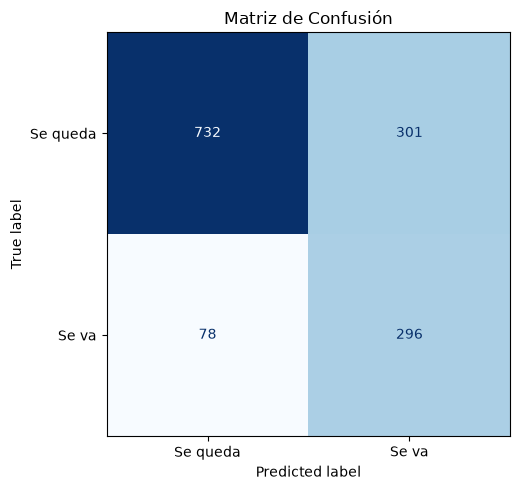

In [15]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Se queda', 'Se va'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de Confusión')
plt.tight_layout()
plt.show()

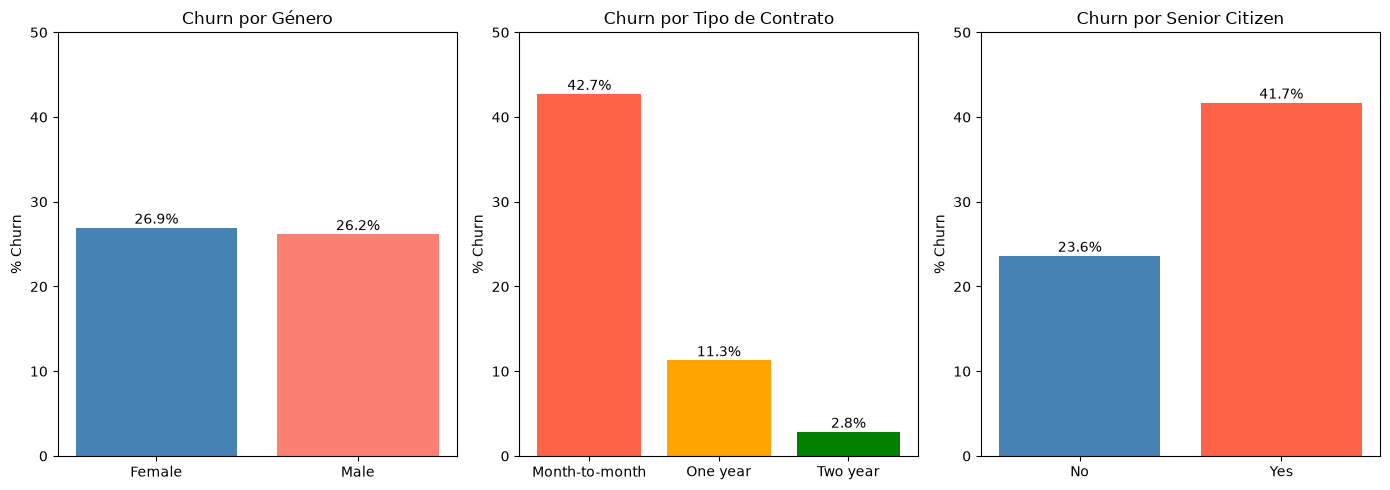

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# 1. Género
axes[0].bar(churn_genero.index, churn_genero.values, color=['steelblue', 'salmon'])
axes[0].set_title('Churn por Género')
axes[0].set_ylabel('% Churn')
axes[0].set_ylim(0, 50)
for i, v in enumerate(churn_genero.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center')

# 2. Tipo de contrato
axes[1].bar(churn_contrato.index, churn_contrato.values, color=['tomato', 'orange', 'green'])
axes[1].set_title('Churn por Tipo de Contrato')
axes[1].set_ylabel('% Churn')
axes[1].set_ylim(0, 50)
for i, v in enumerate(churn_contrato.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center')

# 3. Senior Citizen
axes[2].bar(churn_senior.index, churn_senior.values, color=['steelblue', 'tomato'])
axes[2].set_title('Churn por Senior Citizen')
axes[2].set_ylabel('% Churn')
axes[2].set_ylim(0, 50)
for i, v in enumerate(churn_senior.values):
    axes[2].text(i, v + 0.5, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

## Interpretación de Resultados

El modelo de regresión logística evaluó 1,407 clientes que nunca había visto.

- **Accuracy 73%** — el modelo acierta en 7 de cada 10 casos. 
  Pero con 26.6% de churn real, un modelo que predice siempre "se queda" 
  tendría 73.4% de accuracy sin detectar ningún churner. Por eso la accuracy 
  sola no dice nada útil acá.
- **Recall 79%** — de los 374 clientes que realmente se fueron, 
  el modelo detectó 296. Solo dejó escapar 78.
- **Precision 49%** — de los 597 clientes que el modelo marcó como "se va", 
  solo 296 realmente se fueron. Generó 301 falsas alarmas.
- **F1 0.61** — balance razonable dado el desbalance del dataset.

Para un sistema de retención el Recall es la métrica más importante — 
es mejor llamar a clientes que no iban a irse que perder los que sí se van.
Con un error de retención de $5 por llamada y 301 falsas alarmas, 
el costo es $1,505. Si cada cliente retenido vale más que eso, el modelo es rentable.

## Análisis Exploratorio: ¿Quiénes se van?

**Género:** Prácticamente no hay diferencia entre hombres y mujeres (26.2% vs 26.9%).
El género no es un factor predictor relevante del churn.

**Tipo de contrato:** Es la variable con mayor impacto.
- Mes a mes: 42.7% de churn — los clientes sin compromiso pueden cancelar cuando quieren, y casi la mitad lo hace
- Un año: 11.3% — al haber firmado por un año tienen menos incentivo de irse en el medio
- Dos años: 2.8% — casi ninguno abandona, están atados por más tiempo y probablemente obtuvieron mejores condiciones al firmar

A menor compromiso contractual, mayor riesgo de churn.

**Senior Citizen:** Los clientes mayores tienen el doble de churn (41.7% vs 23.6%).
Esto sugiere que pueden tener dificultades con el servicio o encontrar mejores alternativas.

## Conclusiones y Decisiones de Negocio

### Resultados del modelo
El modelo detecta el 79% de los clientes que se van (Recall 0.79).
De cada 10 clientes que el modelo marca como "riesgo", 5 realmente se van (Precision 0.50).

Ese trade-off es intencional: en churn, preferimos alertar de más (falsos positivos)
antes que dejar ir clientes sin intervenir (falsos negativos).
Retener un cliente es más barato que conseguir uno nuevo.

### Decisiones de negocio que habilita este modelo

**1. Priorizar clientes mes a mes**
El 42.7% de clientes con contrato mensual hace churn. Ofrecerles un descuento
para migrar a contrato anual reduciría el churn a menos del 11%.
Acción: campaña de retención dirigida a los ~3,800 clientes mes a mes que el
modelo clasifica como riesgo alto.

**2. Programa especial para Senior Citizens**
Los mayores hacen churn al doble de tasa (41.7%). Probablemente necesitan
soporte adicional o planes simplificados.
Acción: asignar un agente de atención dedicado a clientes mayores en riesgo.

**3. Umbral de decisión ajustable**
El modelo usa un umbral de 0.5 por defecto. Si el equipo comercial quiere
ser más agresivo en retención (contactar más gente aunque sea falsa alarma),
puede bajarse a 0.3 para aumentar el Recall.
Si el presupuesto de retención es limitado y solo se puede contactar a pocos,
subir el umbral a 0.6 mejora la Precision.

### Limitación principal
Con regresión logística logramos un F1 de 0.61. Para mejorar la Precision
sin sacrificar Recall se necesitaría un modelo más complejo que capture relaciones no lineales entre las variables.

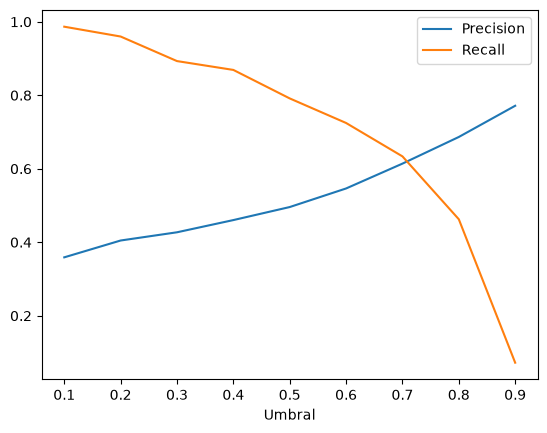

In [17]:
# Le pido al modelo las probabilidades de churn para cada cliente del test
# predict_proba devuelve 2 columnas: prob de clase 0 y prob de clase 1
# [:, 1] agarra solo la columna de "se va" — un número entre 0 y 1 por cliente
y_prob = modelo.predict_proba(X_test)[:, 1]

# Los umbrales que vamos a probar
# Listas vacías donde vamos a guardar los resultados de cada umbral
umbrales = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
precisiones = []
recalls = []

for umbral in umbrales:
    # Si la probabilidad del cliente es mayor al umbral → predecimos churn (1), sino (0)
    # astype(int) convierte True/False a 1/0
    y_pred = (y_prob >= umbral).astype(int)
    
    # Calculamos Precision y Recall con ese umbral y los guardamos
    precisiones.append(precision_score(y_test, y_pred))
    recalls.append(recall_score(y_test, y_pred))

# Graficamos ambas curvas — umbral en el eje X, métrica en el eje Y
plt.plot(umbrales, precisiones, label='Precision')
plt.plot(umbrales, recalls, label='Recall')
plt.xlabel('Umbral')
plt.legend()
plt.show()

## Análisis de Umbral de Decisión

Con el umbral por defecto de 0.5 el modelo prioriza el Recall — detecta más churners
pero genera más falsas alarmas. Las curvas se cruzan alrededor de 0.65, que es el punto
donde Precision y Recall están equilibrados.

Elegir el umbral depende de la estrategia del negocio:
- Si el presupuesto de retención es amplio → bajar el umbral para no perder ningún churner
- Si el presupuesto es limitado → subir el umbral para contactar solo a los casos más seguros

### 🎚️ Ejercicio 3 — Mové el umbral: 0.3 vs 0.7 (Churn, ~8 min)

**Consigna:** el modelo por defecto usa umbral 0.5. Calculá `y_proba = modelo_c.predict_proba(X_test_c)[:, 1]` y compará qué pasa con Precision y Recall si usás umbral **0.3** (atrapar más) vs **0.7** (alertas más seguras).

**Pista buscable:** `sklearn predict_proba threshold precision recall example` — es solo `(y_proba >= umbral).astype(int)` + `precision_score` / `recall_score`.

**Conexión con tu proyecto:** es la misma curva de umbral 0.1–0.9 de `churn.ipynb` (cruce ~0.65), pero acá solo comparás 2 puntos. ¿Con presupuesto amplio (muchas llamadas) o limitado (pocas llamadas) a dónde moverías el umbral?

In [22]:
y_proba = modelo.predict_proba(X_test)[:, 1]
umbral1 = 0.3
umbral2 = 0.7

y_prod = (y_proba >= umbral1).astype(int)
y_prod2 = (y_proba >= umbral2).astype(int)


prec1 = precision_score(y_test, y_prod)
recall1 = recall_score(y_test, y_prod)

prec2 =  precision_score(y_test, y_prod2)
recall2 = recall_score(y_test, y_prod2)

print(f"Umbral: {umbral1}, Precision: {prec1:.2f}, Recall: {recall1:.2f}")
print(f"Umbral: {umbral2}, Precision: {prec2:.2f}, Recall: {recall2:.2f}")

Umbral: 0.3, Precision: 0.43, Recall: 0.89
Umbral: 0.7, Precision: 0.61, Recall: 0.63
